In [ ]:
import os
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()

DATA_PATH = Path(
    os.getenv("DATA_PATH", "yellow_tripdata_2026-05_clean.parquet")
).expanduser()

OUTPUT_DIR = Path(
    os.getenv("OUTPUT_DIR", "outputs")
).expanduser()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"데이터 파일을 찾을 수 없습니다: {DATA_PATH}\n"
        "Colab에서는 파일을 /content에 업로드하고, "
        "로컬에서는 .env의 DATA_PATH를 확인해주세요."
    )

print(f"데이터: {DATA_PATH.resolve()}")
print(f"결과 저장: {OUTPUT_DIR.resolve()}")

데이터: /content/yellow_tripdata_2026-05_clean.parquet
결과 저장: /content/outputs


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

## 시각화(Visualization) — 통계 분석 전 데이터 개요

가설별 통계 검정(H1, H2, ...)에 들어가기 전에, 전체 데이터가 어떤 모양인지 먼저 눈으로 확인한다. 통계 검정을 돌리기 전에 데이터를 보지 않으면 결과 해석에서 실수하기 쉽다.

- **정적 시각화 (Seaborn)**: 운행 거리(`trip_distance`) 분포 — 대부분의 운행이 얼마나 짧은지, 공항 운행이 분포를 어떻게 다르게 만드는지 확인한다.
- **동적 시각화 (Plotly)**: 시간대별 운행 수요 패턴 — 평일과 주말의 하루 중 수요 곡선이 어떻게 다른지 hover로 정확한 수치를 확인하며 탐색한다.

In [ ]:
import seaborn as sns
import plotly.express as px

# 이후 두 차트가 함께 쓰는 데이터. pickup_dt는 평일/주말 날짜 수를 세기 위해 필요하다.
eda_columns = ["pickup_dt", "trip_distance", "is_airport_trip", "pickup_hour", "is_weekend"]
eda_trips = pd.read_parquet(DATA_PATH, columns=eda_columns)
eda_trips["pickup_date"] = eda_trips["pickup_dt"].dt.date
print(f"시각화 대상: {len(eda_trips):,}건")

EDA_BLUE, EDA_ORANGE, EDA_GRAY = "#2a78d6", "#eb6834", "#898781"


시각화 대상: 3,881,420건


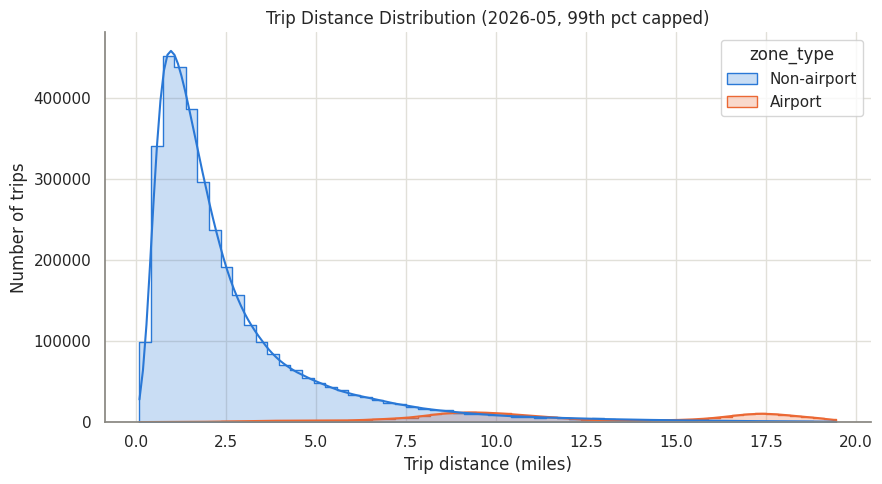

In [ ]:
# 정적 시각화(Seaborn): 운행 거리 분포. 상위 1%는 공항 왕복 등 극단적으로 긴 거리라
# 히스토그램 전체 형태를 눌러버리므로 99분위수로 절사해서 표시한다.
eda_dist_cap = eda_trips["trip_distance"].quantile(0.99)
eda_dist_plot = eda_trips.loc[eda_trips["trip_distance"] <= eda_dist_cap].copy()
eda_dist_plot["zone_type"] = eda_dist_plot["is_airport_trip"].map({True: "Airport", False: "Non-airport"})

sns.set_theme(style="whitegrid", rc={"axes.edgecolor": EDA_GRAY, "grid.color": "#e1e0d9"})
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=eda_dist_plot, x="trip_distance", hue="zone_type", hue_order=["Non-airport", "Airport"],
    palette=[EDA_BLUE, EDA_ORANGE], bins=60, kde=True, element="step", ax=ax,
)
ax.set_title("Trip Distance Distribution (2026-05, 99th pct capped)")
ax.set_xlabel("Trip distance (miles)")
ax.set_ylabel("Number of trips")
for eda_spine in ["top", "right"]:
    ax.spines[eda_spine].set_visible(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "eda_trip_distance_hist.png", dpi=150)
plt.show()


In [ ]:
# 동적 시각화(Plotly): 평일 vs 주말 시간대별 운행 수요 패턴.
# 2026년 5월은 평일 21일, 주말 10일로 날짜 수가 다르다. 단순 합계로 비교하면
# 날짜 수가 많은 평일이 항상 높게 나오는 착시가 생기므로, 날짜 수로 나눠
# "하루 평균 운행 건수"로 정규화해야 공정하게 비교할 수 있다.
eda_n_days = eda_trips.groupby("is_weekend")["pickup_date"].nunique()
eda_hourly = eda_trips.groupby(["pickup_hour", "is_weekend"]).size().reset_index(name="trips")
eda_hourly["group"] = eda_hourly["is_weekend"].map({True: "Weekend", False: "Weekday"})
eda_hourly["n_days"] = eda_hourly["is_weekend"].map(eda_n_days)
eda_hourly["avg_trips_per_day"] = eda_hourly["trips"] / eda_hourly["n_days"]

eda_fig = px.line(
    eda_hourly, x="pickup_hour", y="avg_trips_per_day", color="group",
    category_orders={"group": ["Weekday", "Weekend"]},
    color_discrete_map={"Weekday": EDA_BLUE, "Weekend": EDA_ORANGE},
    markers=True,
    labels={"pickup_hour": "Pickup hour", "avg_trips_per_day": "Avg trips per day", "group": ""},
    hover_data={"trips": True, "n_days": True},
    title="Hourly Demand Pattern: Weekday vs Weekend (avg trips/day, 2026-05)",
)
eda_fig.update_layout(
    xaxis=dict(dtick=1, title="Pickup hour (0-23)"),
    yaxis=dict(title="Average trips per day"),
    legend_title_text="",
    hovermode="x unified",
)
eda_fig.write_html(str(OUTPUT_DIR / "eda_hourly_demand.html"))  # 브라우저에서 열 수 있는 인터랙티브 파일로 저장
eda_fig.show()


## H1. 수요 집중성(Demand Concentration) 분석

**가설(H1)**: 뉴욕시 옐로우 택시 운행의 상위 20% 구역(Zone, `pu_location_id`)이 전체 수익(`total_amount`)의 60% 이상을 차지하며, 이 구역은 로보택시 집중 배차의 핵심 타겟이다.

**검증 방법**

1. `pu_location_id`별 총수익을 집계하고 내림차순 정렬한다.
2. Pareto 분석: 상위 20% Zone의 누적 수익 비율을 계산해 60% 기준과 비교한다.
3. Gini 계수와 Lorenz Curve로 집중도를 하나의 숫자·그래프로 요약한다.
4. 공항 Zone(JFK=132, LaGuardia=138, Newark=1)은 정액 요금이라 결과가 왜곡될 수 있으므로, 포함/제외 두 버전으로 나눠 재검증한다.

In [ ]:
# H1 분석에 필요한 컬럼만 선택적으로 로딩 (390만 행 전체를 메모리에 올리지 않기 위함)
h1_columns = ["pu_location_id", "do_location_id", "total_amount", "is_airport_trip"]
h1_trips = pd.read_parquet(DATA_PATH, columns=h1_columns)
print(f"H1 분석 대상: {len(h1_trips):,}건 (전처리 완료 데이터 그대로 사용, 추가 행 제거 없음)")

# Zone(pu_location_id)별 총수익 집계 -> 내림차순 정렬
# H1의 출발점: "수익이 특정 구역에 몰려있는가"를 보려면 먼저 Zone별 합계가 필요하다.
h1_zone = (
    h1_trips.groupby("pu_location_id")
    .agg(trips=("total_amount", "size"), revenue=("total_amount", "sum"))
    .sort_values("revenue", ascending=False)
)
h1_zone["revenue_share"] = h1_zone["revenue"] / h1_zone["revenue"].sum()
h1_zone["cum_revenue_share"] = h1_zone["revenue_share"].cumsum()
h1_zone["avg_fare_per_trip"] = h1_zone["revenue"] / h1_zone["trips"]

h1_total_revenue = h1_zone["revenue"].sum()
h1_n_zones = len(h1_zone)
print(f"확인된 Zone 수: {h1_n_zones}개")
print(f"전체 수익 합계: ${h1_total_revenue:,.0f}")

display(h1_zone.head(10))


H1 분석 대상: 3,881,420건 (전처리 완료 데이터 그대로 사용, 추가 행 제거 없음)
확인된 Zone 수: 259개
전체 수익 합계: $118,293,392


,trips,revenue,revenue_share,cum_revenue_share,avg_fare_per_trip
pu_location_id,,,,,
132,140717,11349426.00,0.095943,0.095943,80.654264
138,102565,7450879.00,0.062986,0.158929,72.645435
161,154507,4325620.00,0.036567,0.195496,27.996272
237,190041,4279197.50,0.036174,0.231671,22.517233
236,167598,3837906.50,0.032444,0.264115,22.899477
230,107071,3351557.25,0.028333,0.292447,31.302194
162,115695,3099789.75,0.026204,0.318652,26.792772
186,109428,3046448.75,0.025753,0.344405,27.839755
142,119369,2901786.25,0.024530,0.368935,24.309379


In [ ]:
# Pareto(80/20) 분석: 상위 20%, 상위 10% Zone이 전체 수익에서 차지하는 비율
# round()를 쓰는 이유: Zone 수가 정확히 5·10의 배수가 아니므로 정수 Zone 개수로 변환해야 한다.
h1_top20_n = round(h1_n_zones * 0.20)
h1_top10_n = round(h1_n_zones * 0.10)
h1_top20_share = h1_zone["revenue_share"].iloc[:h1_top20_n].sum()
h1_top10_share = h1_zone["revenue_share"].iloc[:h1_top10_n].sum()

print(f"상위 20% Zone ({h1_top20_n}개 / 전체 {h1_n_zones}개) 수익 비율: {h1_top20_share:.1%}")
print(f"상위 10% Zone ({h1_top10_n}개) 수익 비율: {h1_top10_share:.1%}")

# 누적 수익이 60%, 80%를 넘는 시점이 정확히 몇 번째 Zone인지도 함께 확인한다.
# "상위 20%"라는 임의의 절단선 대신, 실제 데이터가 만드는 절단선을 보기 위함이다.
for h1_target in [0.60, 0.80]:
    h1_rank = int(np.searchsorted(h1_zone["cum_revenue_share"].values, h1_target) + 1)
    print(f"누적 수익 {h1_target:.0%} 도달 시점: 상위 {h1_rank}개 Zone ({h1_rank / h1_n_zones:.1%})")

# 가설 기준(60%)과 비교해 채택 여부를 코드로 직접 판정한다.
# 사람이 눈으로 보고 판단하지 않고 코드에 기준을 명시하는 이유: report.md 자동 생성 시
# 그대로 재사용할 수 있고, 데이터가 갱신돼도 같은 기준으로 재현 가능하기 때문이다.
H1_PARETO_THRESHOLD = 0.60
h1_pareto_supported = bool(h1_top20_share >= H1_PARETO_THRESHOLD)
print(
    f"H1 판정 (기준: 상위 20% Zone 수익 비율 >= {H1_PARETO_THRESHOLD:.0%}): "
    f"{'채택(Supported)' if h1_pareto_supported else '기각/수정 필요'}"
)


상위 20% Zone (52개 / 전체 259개) 수익 비율: 88.9%
상위 10% Zone (26개) 수익 비율: 67.8%
누적 수익 60% 도달 시점: 상위 21개 Zone (8.1%)
누적 수익 80% 도달 시점: 상위 37개 Zone (14.3%)
H1 판정 (기준: 상위 20% Zone 수익 비율 >= 60%): 채택(Supported)


Gini 계수: 0.812


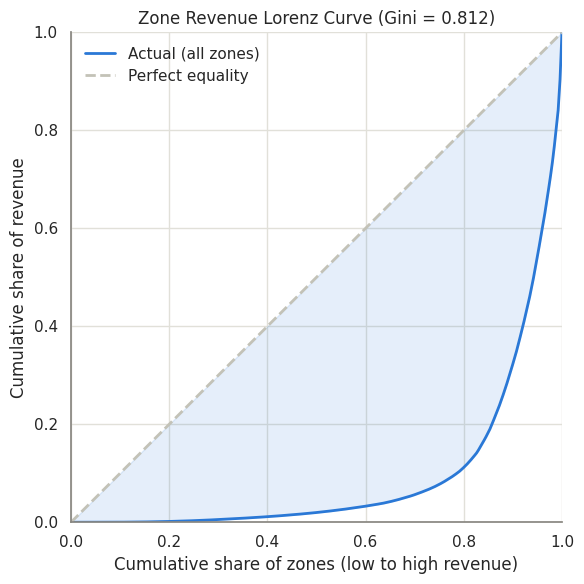

In [ ]:
# 팔레트: 실측 계열은 파랑(카테고리 슬롯1), 완전균등 기준선은 중립 회색 점선,
# 비교 계열(공항 제외)은 주황(카테고리 슬롯2)으로 구분한다. 차트 텍스트는
# 한글 폰트 미설치 환경(Colab 기본 이미지 등)에서 글자가 깨지는 문제를 피하기 위해
# H2 셀과 동일하게 영어로 작성한다.
H1_BLUE, H1_GRAY, H1_ORANGE = "#2a78d6", "#c3c2b7", "#eb6834"


def gini_coefficient(values):
    """Gini 계수: 0(완전 균등)~1(완전 불균등). 오름차순 정렬 후 가중 누적합 공식을 사용한다."""
    v = np.sort(np.asarray(values, dtype=float))
    n = len(v)
    cum = np.cumsum(v)
    return float((2 * np.sum(np.arange(1, n + 1) * v) - (n + 1) * cum[-1]) / (n * cum[-1]))


def lorenz_curve_points(values):
    """Lorenz Curve 좌표: (Zone 누적 비율, 수익 누적 비율). 수익이 낮은 Zone부터 정렬한다."""
    v = np.sort(np.asarray(values, dtype=float))
    cum_share = np.concatenate([[0.0], np.cumsum(v) / v.sum()])
    pop_share = np.linspace(0.0, 1.0, len(v) + 1)
    return pop_share, cum_share


h1_gini = gini_coefficient(h1_zone["revenue"].values)
h1_pop_share, h1_cum_share = lorenz_curve_points(h1_zone["revenue"].values)
print(f"Gini 계수: {h1_gini:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(h1_pop_share, h1_cum_share, color=H1_BLUE, linewidth=2, label="Actual (all zones)")
ax.plot([0, 1], [0, 1], color=H1_GRAY, linewidth=2, linestyle="--", label="Perfect equality")
ax.fill_between(h1_pop_share, h1_pop_share, h1_cum_share, color=H1_BLUE, alpha=0.12)
ax.set_title(f"Zone Revenue Lorenz Curve (Gini = {h1_gini:.3f})")
ax.set_xlabel("Cumulative share of zones (low to high revenue)")
ax.set_ylabel("Cumulative share of revenue")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="upper left", frameon=False)
for h1_spine in ["top", "right"]:
    ax.spines[h1_spine].set_visible(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "h1_lorenz_curve.png", dpi=150)  # 발표 PDF·report.md에서 재사용
plt.show()


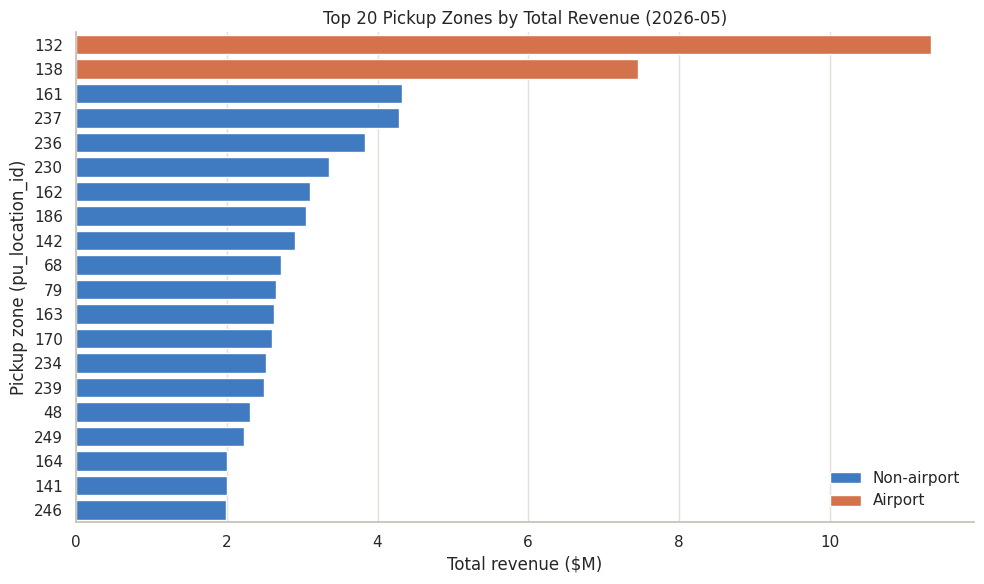

Tier A 후보(상위 20% Zone 중 시내 Zone): 50개


,trips,revenue,revenue_share
pu_location_id,,,
161,154507,4325620.00,0.036567
237,190041,4279197.50,0.036174
236,167598,3837906.50,0.032444
230,107071,3351557.25,0.028333
162,115695,3099789.75,0.026204
186,109428,3046448.75,0.025753
142,119369,2901786.25,0.024530
68,94591,2718108.50,0.022978
79,102695,2656769.75,0.022459


In [ ]:
import seaborn as sns

# 02_preprocess.py의 AIRPORT_ZONES 정의를 그대로 재사용해 상위 20개 Zone 중
# 공항 Zone을 색으로 구분한다(Zone Lookup 테이블 없이도 식별 가능).
H1_AIRPORT_ZONES = {1, 132, 138}
h1_top20 = h1_zone.head(20).reset_index()
h1_top20["zone_type"] = h1_top20["pu_location_id"].isin(H1_AIRPORT_ZONES).map(
    {True: "Airport", False: "Non-airport"}
)

sns.set_theme(style="whitegrid", rc={"axes.edgecolor": H1_GRAY, "grid.color": "#e1e0d9"})
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=h1_top20, x=h1_top20["revenue"] / 1e6, y=h1_top20["pu_location_id"].astype(str),
    hue="zone_type", hue_order=["Non-airport", "Airport"], palette=[H1_BLUE, H1_ORANGE], ax=ax,
)
ax.set_title("Top 20 Pickup Zones by Total Revenue (2026-05)")
ax.set_xlabel("Total revenue ($M)")
ax.set_ylabel("Pickup zone (pu_location_id)")
ax.legend(title="", loc="lower right", frameon=False)
for h1_spine in ["top", "right"]:
    ax.spines[h1_spine].set_visible(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "h1_top20_zone_bar.png", dpi=150)
plt.show()

# 로보택시 우선 배차 Tier A 후보: 상위 20% Zone 중 공항을 제외한 시내 Zone.
# 공항은 배차 허가·공항 측 협약 등 별도 전략이 필요해 여기서는 후보에서 제외한다.
h1_tier_a_top20 = h1_zone.head(h1_top20_n)
h1_tier_a_candidates = h1_tier_a_top20.loc[~h1_tier_a_top20.index.isin(H1_AIRPORT_ZONES)]
print(f"Tier A 후보(상위 20% Zone 중 시내 Zone): {len(h1_tier_a_candidates)}개")
display(h1_tier_a_candidates.head(10)[["trips", "revenue", "revenue_share"]])


### H1 결론

`yellow_tripdata_2026-05_clean.parquet` 389만 건 기준 실행 결과:

| 지표 | 값 |
|---|---:|
| 확인된 Zone 수 | 259개 |
| 상위 20% Zone(52개) 수익 비율 | **88.9%** |
| 상위 10% Zone(26개) 수익 비율 | 67.8% |
| 누적 수익 60% 도달 시점 | 상위 21개 Zone (전체의 8.1%) |
| 누적 수익 80% 도달 시점 | 상위 37개 Zone (전체의 14.3%) |
| Gini 계수 (전체) | **0.812** |
| Gini 계수 (공항 제외) | 0.790 |
| Gini 계수 (공항만) | 0.947 |

**판정**: 상위 20% Zone이 60% 기준을 크게 초과하는 88.9%의 수익을 창출하므로 **H1은 강하게 채택(Supported)** 된다. Gini 0.812는 "매우 강한 집중도" 구간(0.8 이상)에 해당한다.

**공항 Zone 분리 검증**: JFK(132)·LaGuardia(138)를 제외해도 Gini가 0.812 → 0.790으로 소폭 낮아질 뿐, 여전히 매우 강한 집중도를 유지한다. 즉 수익 집중은 공항 두 곳의 정액 요금 때문에 생긴 착시가 아니라, 맨해튼 중심가 등 일반 시내 Zone 사이에서도 실제로 존재하는 구조적 패턴이다. 반대로 공항만 따로 보면 Gini가 0.947까지 올라가는데, 이는 219개 공항 관련 Zone 중에서도 JFK·LaGuardia 단 두 곳이 압도적으로 수익을 독점하기 때문이다.

**로보택시 전략 시사점**: 로보택시를 259개 전체 Zone에 균등 배치할 필요가 없다. 상위 20% Zone(52개) — 이 중 공항 2곳을 제외한 50개 Zone을 Tier A 후보로 — 에만 집중 배차해도 전체 수익의 약 90%를 커버할 수 있다. 공항 2곳(JFK·LaGuardia)은 정액 요금·수하물 대기열·배차 허가 등 시내와 다른 운영 조건이 있으므로 별도 전략(공항 측 협약, 전용 승하차 구역)이 필요하다.

산출물: `outputs/h1_lorenz_curve.png`, `outputs/h1_lorenz_airport_split.png`, `outputs/h1_top20_zone_bar.png`, `h1_summary`(코드 변수)